# 🧠 Neural Networks from Scratch

**Goal:** By the end of this notebook, you'll understand exactly what happens
when someone says "the model is training." No magic, no hand-waving.

We'll build a neural network using only NumPy (basic math), train it to solve
a problem that a single neuron *cannot* solve, and then see how PyTorch
automates what we did manually.

---

## What We'll Cover
1. **The XOR Problem** — Why we need hidden layers
2. **Building a Neural Network** — Forward pass from scratch
3. **The Training Loop** — Loss, backprop, weight updates
4. **Watching It Learn** — Visualizing training
5. **Breaking It** — What happens with bad hyperparameters
6. **PyTorch Version** — Same thing, less code

Let's go.

# Part 1: The XOR Problem

## Why XOR?

XOR (exclusive or) is a simple logical operation:
- If inputs are **different** → output 1
- If inputs are **the same** → output 0

| Input A | Input B | Output |
|---------|---------|--------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

### The Historical Importance

In 1969, Minsky and Papert proved that a single-layer perceptron (one neuron)
**cannot learn XOR**. This caused the first "AI Winter" — people thought neural
networks were fundamentally limited.

The solution? **Hidden layers.** A network with at least one hidden layer CAN
learn XOR. This notebook proves it.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# our training data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])


In [5]:
print("XOR dataset :")
print("-" * 30 ) 

for i in range(len(X)):
    print(f"Input: {X[i]} → Output: {y[i][0]}")



XOR dataset :
------------------------------
Input: [0 0] → Output: 0
Input: [0 1] → Output: 1
Input: [1 0] → Output: 1
Input: [1 1] → Output: 0



### Visualizing the Problem

Let's plot the XOR data. You'll see why a straight line can't separate the classes.


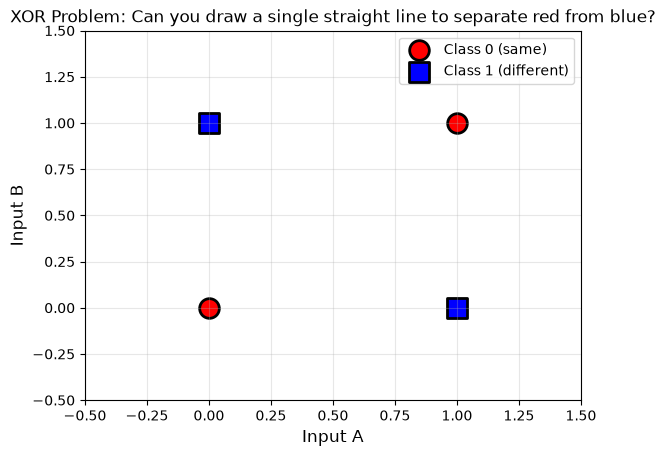


❌ A single straight line CANNOT separate these classes.
✅ This is why we need hidden layers — they create non-linear boundaries.


In [6]:
# Plot tplt.figure(figsize=(8, 6))

# Plot the points
for i in range(len(X)):
    color = 'red' if y[i][0] == 0 else 'blue'
    marker = 'o' if y[i][0] == 0 else 's'
    plt.scatter(X[i][0], X[i][1], c=color, s=200, marker=marker,
                edgecolors='black', linewidths=2)

plt.xlabel('Input A', fontsize=12)
plt.ylabel('Input B', fontsize=12)
plt.title('XOR Problem: Can you draw a single straight line to separate red from blue?',
          fontsize=12)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.legend(['Class 0 (same)', 'Class 1 (different)'], loc='upper right')
plt.show()

print("\n❌ A single straight line CANNOT separate these classes.")
print("✅ This is why we need hidden layers — they create non-linear boundaries.")


---
# Part 2: Building the Neural Network

## Our Architecture

```
Input Layer (2 neurons) → Hidden Layer (4 neurons) → Output Layer (1 neuron)
```

- **Input:** 2 values (the two XOR inputs)
- **Hidden:** 4 neurons with sigmoid activation
- **Output:** 1 neuron with sigmoid activation (gives us 0-1 probability)

### Why Sigmoid?

For this educational example, we use sigmoid everywhere because:
1. Output is naturally between 0 and 1 (matches our target)
2. The math is clean and easy to follow
3. It's historically important

In practice, you'd use ReLU for hidden layers. But sigmoid helps us see
what's happening.

In [7]:

# Network architecture
INPUT_SIZE = 2    # Two inputs (A and B)
HIDDEN_SIZE = 4   # Four neurons in hidden layer
OUTPUT_SIZE = 1   # One output (0 or 1)


In [8]:
# Weights from input to hidden layer (2 inputs → 4 hidden neurons)
weights_input_hidden = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))

In [9]:
# Weights from hidden to output layer (4 hidden neurons → 1 output)
weights_hidden_output = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros((1, OUTPUT_SIZE))

In [10]:
print("Network initialized with random weights:")
print(f"  Input → Hidden weights shape: {weights_input_hidden.shape}")
print(f"  Hidden → Output weights shape: {weights_hidden_output.shape}")
print(f"\nTotal parameters: {weights_input_hidden.size + bias_hidden.size + weights_hidden_output.size + bias_output.size}")

Network initialized with random weights:
  Input → Hidden weights shape: (2, 4)
  Hidden → Output weights shape: (4, 1)

Total parameters: 17


## The Activation Function: Sigmoid

Sigmoid squashes any number into the range (0, 1):
- Large positive numbers → close to 1
- Large negative numbers → close to 0
- Zero → exactly 0.5

We also need its derivative for backpropagation.

In [11]:
def sigmoid(x):
    """Squash values to range (0, 1)"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid: σ(x) * (1 - σ(x))"""
    s = sigmoid(x)
    return s * (1 - s)


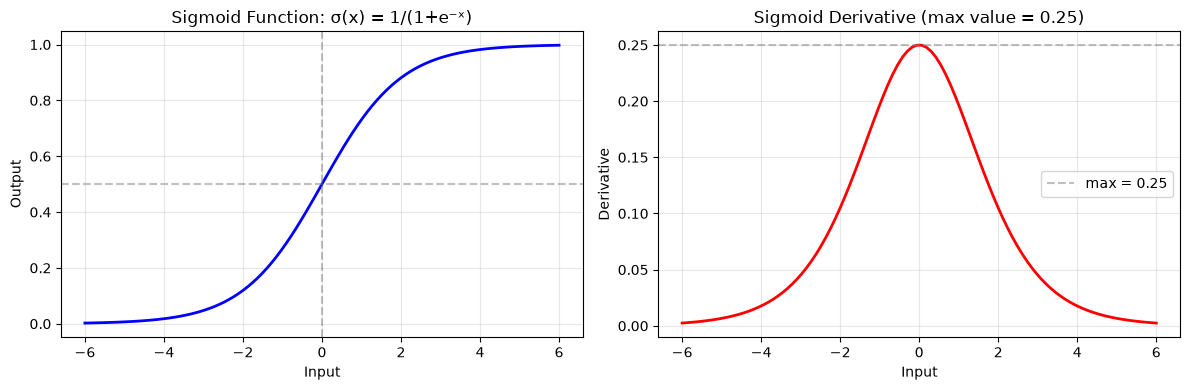

In [12]:
# Visualize sigmoid
x_range = np.linspace(-6, 6, 100)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_range, sigmoid(x_range), 'b-', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid Function: σ(x) = 1/(1+e⁻ˣ)')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(x_range, sigmoid_derivative(x_range), 'r-', linewidth=2)
plt.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='max = 0.25')
plt.xlabel('Input')
plt.ylabel('Derivative')
plt.title('Sigmoid Derivative (max value = 0.25)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\nNotice: The maximum derivative is only 0.25!")
print("   This is the vanishing gradient problem.")
print("   10 layers: 0.25^10 = ", 0.25**10)

## Forward Pass

The forward pass is how data flows through the network:

1. **Input → Hidden:** Multiply inputs by weights, add bias, apply activation
2. **Hidden → Output:** Multiply hidden by weights, add bias, apply activation

Let's trace through exactly what happens.

In [13]:
def forward(X):
    """
    Forward pass through the network.
    Returns all intermediate values (we need them for backprop).
    """
    # Step 1: Input to Hidden
    # z_hidden = X @ W + b (linear combination)
    z_hidden = np.dot(X, weights_input_hidden) + bias_hidden

    # a_hidden = sigmoid(z_hidden) (activation)
    a_hidden = sigmoid(z_hidden)

    # Step 2: Hidden to Output
    # z_output = a_hidden @ W + b
    z_output = np.dot(a_hidden, weights_hidden_output) + bias_output

    # a_output = sigmoid(z_output)
    a_output = sigmoid(z_output)

    # Return everything (we need z values for backprop)
    return z_hidden, a_hidden, z_output, a_output

In [14]:
# Test forward pass with untrained network
z_h, a_h, z_o, predictions = forward(X)

In [15]:
print("Forward pass with UNTRAINED network:")
print("-" * 50)
for i in range(len(X)):
    print(f"Input: {X[i]} → Prediction: {predictions[i][0]:.4f} (Target: {y[i][0]})")

print("\n❌ Predictions are garbage — the network hasn't learned anything yet.")

Forward pass with UNTRAINED network:
--------------------------------------------------
Input: [0 0] → Prediction: 0.3479 (Target: 0)
Input: [0 1] → Prediction: 0.3288 (Target: 1)
Input: [1 0] → Prediction: 0.3582 (Target: 1)
Input: [1 1] → Prediction: 0.3396 (Target: 0)

❌ Predictions are garbage — the network hasn't learned anything yet.


## Loss Function: Mean Squared Error

Loss measures **how wrong** our predictions are. Lower = better.

**MSE = mean((prediction - target)²)**

We square the error so:
- All errors are positive
- Big errors are penalized more than small errors

In [16]:
def compute_loss(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)

In [17]:
# Calculate initial loss
initial_loss = compute_loss(y, predictions)
print(f"Initial Loss (untrained): {initial_loss:.4f}")
print("\nThis number should decrease as we train.")

Initial Loss (untrained): 0.2747

This number should decrease as we train.


# Part 3: Backpropagation

This is where the magic happens. Backprop answers: **"Which weights caused the error, and how much?"**

## The Chain of Blame

1. Calculate error at output
2. Figure out how much each output weight contributed
3. Propagate error back to hidden layer
4. Figure out how much each hidden weight contributed
5. Adjust all weights proportionally

The math uses the chain rule from calculus, but the intuition is simple:
**blame flows backward.**

In [ ]:
def backward(X, y, z_hidden, a_hidden, z_output, a_output, learning_rate):
    """
    Backpropagation: compute gradients and update weights.
    """
    global weights_input_hidden, bias_hidden, weights_hidden_output, bias_output

    m = X.shape[0]  # Number of training examples

    # ============ OUTPUT LAYER ============
    # Error at output: difference between prediction and target
    output_error = a_output - y  # Shape: (4, 1)

    # Gradient of loss w.r.t. z_output (before activation)
    # This combines the error with the sigmoid derivative
    output_delta = output_error * sigmoid_derivative(z_output)  # Shape: (4, 1)

    # Gradient of loss w.r.t. weights_hidden_output
    # How much did each weight contribute to the error?
    grad_weights_hidden_output = np.dot(a_hidden.T, output_delta) / m
    grad_bias_output = np.mean(output_delta, axis=0, keepdims=True)

    # ============ HIDDEN LAYER ============
    # Propagate error back to hidden layer
    hidden_error = np.dot(output_delta, weights_hidden_output.T)

    # Gradient of loss w.r.t. z_hidden
    hidden_delta = hidden_error * sigmoid_derivative(z_hidden)

    # Gradient of loss w.r.t. weights_input_hidden
    grad_weights_input_hidden = np.dot(X.T, hidden_delta) / m
    grad_bias_hidden = np.mean(hidden_delta, axis=0, keepdims=True)

    # ============ UPDATE WEIGHTS ============
    # Move weights in the opposite direction of the gradient
    # (gradient points uphill, we want to go downhill)
    weights_hidden_output -= learning_rate * grad_weights_hidden_output
    bias_output -= learning_rate * grad_bias_output
    weights_input_hidden -= learning_rate * grad_weights_input_hidden
    bias_hidden -= learning_rate * grad_bias_hidden

print("Backpropagation function defined.")
print("This is the 'learning' part — adjusting weights to reduce error.")